# Feature Selection & Dimensionality Optimization

In [1]:
# imports 

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from catboost import CatBoostClassifier

import shap 


In [6]:
# Create Engineered Dataset

from src.preprocessing import PreprocessConfig, preprocess_train_test
from src.features import FeatureConfig, engineer_train_test_features

# Load raw data
TRAIN_PATH = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Train.csv"
TEST_PATH  = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Test.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

# Initiliaze configs
pre_cfg = PreprocessConfig(
    id_col="ID",
    target_col="Target"
)

feat_cfg = FeatureConfig(
    id_col="ID",
    target_col="Target"
)

#run preprocessing
train_clean, test_clean = preprocess_train_test(
    train_raw,
    test_raw,
    pre_cfg,
    for_model="lightgbm"  # We use "lightgbm" here because the output is fully numeric, which is easier for: correlation analysis, SHAP & feature importance
)

# Run feature engineering
train_fe, test_fe = engineer_train_test_features(
    train_clean,
    test_clean,
    feat_cfg,
    collapse_rare_for_non_catboost=True
)

In [7]:
# Save the Engineered Dataset

import os

os.makedirs("data/processed", exist_ok=True)

train_fe.to_csv("data/processed/train_engineered.csv", index=False)
test_fe.to_csv("data/processed/test_engineered.csv", index=False)

print("Engineered datasets saved.")

Engineered datasets saved.


In [8]:
# Load feature selection

train_df = pd.read_csv("data/processed/train_engineered.csv")

TARGET = "Target"
ID = "ID"

X = train_df.drop(columns=[TARGET, ID])
y = train_df[TARGET]

feature_names = X.columns.tolist()

print("Feature count:", len(feature_names))

Feature count: 117


In [9]:
# Cross-Validation Setup

N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

Train Baseline Models to Collect Feature Importance. We collect feature importance across folds to measure stability.

In [13]:
X.dtypes.value_counts()

float64    55
str        44
int64      18
Name: count, dtype: int64

In [14]:
bad_cols = X.select_dtypes(include=["object"]).columns
print(len(bad_cols))
print(bad_cols)

C:\Users\otsyu\AppData\Local\Temp\ipykernel_14024\1907510790.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  bad_cols = X.select_dtypes(include=["object"]).columns


44
Index(['country', 'attitude_stable_business_environment',
       'attitude_worried_shutdown', 'compliance_income_tax',
       'perception_insurance_doesnt_cover_losses',
       'perception_cannot_afford_insurance', 'motor_vehicle_insurance',
       'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone',
       'owner_sex', 'offers_credit_to_customers',
       'attitude_satisfied_with_achievement', 'has_credit_card',
       'keeps_financial_records',
       'perception_insurance_companies_dont_insure_businesses_like_yours',
       'perception_insurance_important', 'has_insurance',
       'covid_essential_service', 'attitude_more_successful_next_year',
       'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account',
       'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock',
       'medical_insurance', 'funeral_insurance', 'motivation_make_more_money',
       'uses_friends_family_savings', 'uses_informal_lender',
       'business_age_bucket', '

In [15]:
cat_cols = X.select_dtypes(include=["object"]).columns

for col in cat_cols:
    X[col] = X[col].astype("category")

C:\Users\otsyu\AppData\Local\Temp\ipykernel_14024\88062776.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


In [16]:
X.dtypes.value_counts()

float64     55
int64       18
category    10
category     9
category     7
category     2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

 **LightGBM feature importance**

In [ ]:


# Identify categorical columns
cat_cols = X.select_dtypes(include=["category"]).columns.tolist()

lgb_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.02,
        num_leaves=128,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="multi_logloss",
        categorical_feature=cat_cols
    )

    lgb_importances.append(model.feature_importances_)

# aggregate & Convert to dataframe

lgb_importances = np.array(lgb_importances)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_importances.mean(axis=0)
}).sort_values("importance", ascending=False)

importance_df.head(30)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071309 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4085
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 114
[LightGBM] [Info] Start training from score -3.018607
[LightGBM] [Info] Start training from score -0.426214
[LightGBM] [Info] Start training from score -1.210144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

,feature,importance
1,owner_age,32324.2
88,expenses_to_personal_income,28697.8
87,turnover_to_personal_income,27434.8
7,personal_income,22656.6
85,expense_ratio,22323.0
8,business_expenses,22245.4
84,margin_proxy,19756.6
43,business_age_total_months,18236.0
9,business_turnover,17840.4
86,turnover_to_expenses,17723.6


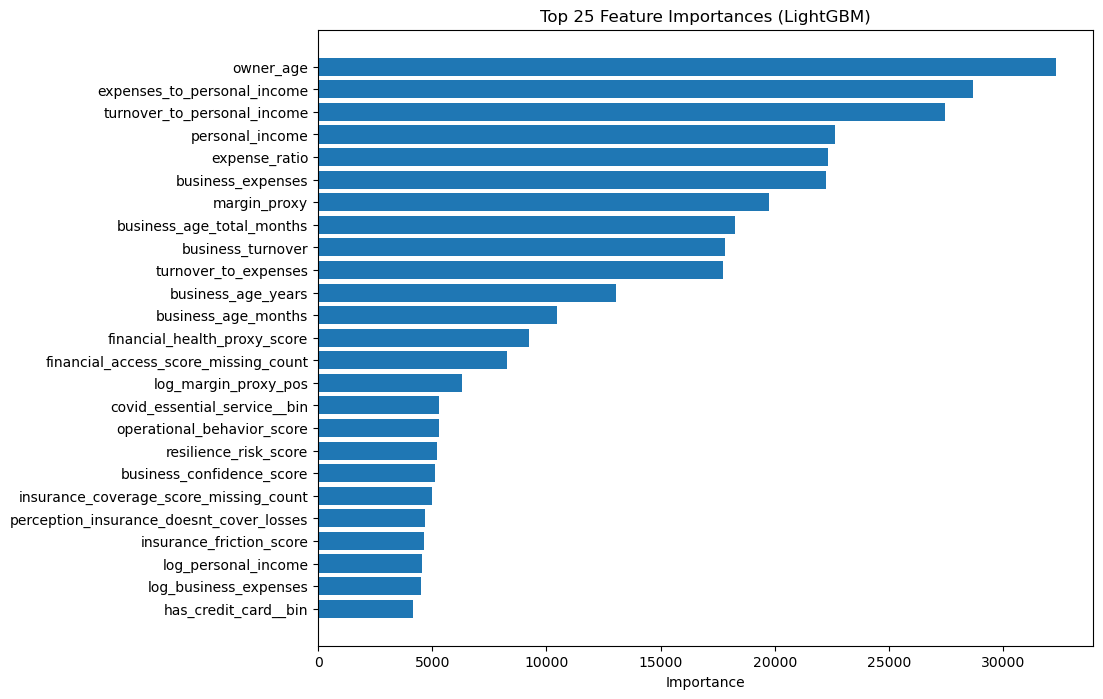

In [21]:
# Visualize top features 

import matplotlib.pyplot as plt

top_n = 25

plt.figure(figsize=(10,8))

plt.barh(
    importance_df.head(top_n)["feature"][::-1],
    importance_df.head(top_n)["importance"][::-1]
)

plt.title("Top 25 Feature Importances (LightGBM)")
plt.xlabel("Importance")
plt.show()

In [22]:
# reduce feature set

top_features = importance_df.head(80)["feature"].tolist()

X_reduced = X[top_features]

print("Original features:", X.shape[1])
print("Reduced features:", X_reduced.shape[1])

Original features: 117
Reduced features: 80


**CatBoost Feature Importance**

In [26]:
cat_importances = []

cat_cols = X.select_dtypes(include=["category"]).columns.tolist()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.03,
        depth=8,
        loss_function="MultiClass",
        eval_metric="TotalF1",
        verbose=False,
        random_seed=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_cols   # ← IMPORTANT
    )

    cat_importances.append(model.get_feature_importance())

In [27]:
# Aggregate feature Importance

cat_importances = np.array(cat_importances)

cat_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": cat_importances.mean(axis=0)
}).sort_values("importance", ascending=False)

cat_importance_df.head(30)

,feature,importance
33,funeral_insurance,26.528373
35,uses_friends_family_savings,3.612359
27,has_loan_account,3.592212
18,has_credit_card,3.194612
29,has_debit_card,2.935347
22,has_insurance,2.708297
47,has_credit_card__bin,2.426901
107,country_x_has_loan_account,1.993100
32,medical_insurance,1.933348
11,motor_vehicle_insurance,1.710476


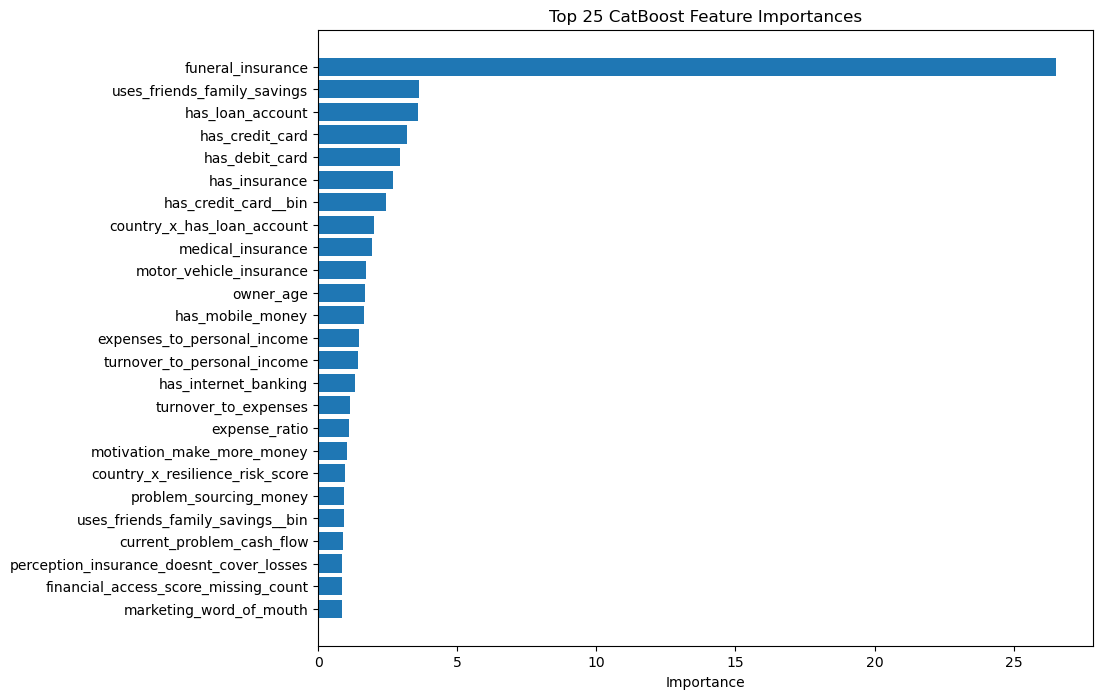

In [28]:
# Plot feature importance

top_n = 25

plt.figure(figsize=(10,8))

plt.barh(
    cat_importance_df.head(top_n)["feature"][::-1],
    cat_importance_df.head(top_n)["importance"][::-1]
)

plt.title("Top 25 CatBoost Feature Importances")
plt.xlabel("Importance")

plt.show()

**Consensus ranking**

Final Importance =
    0.5 * LightGBM importance + 0.5 * CatBoost importance

In [29]:
combined_importance = importance_df.merge(
    cat_importance_df,
    on="feature",
    suffixes=("_lgb","_cat")
)

combined_importance["combined"] = (
    combined_importance["importance_lgb"] +
    combined_importance["importance_cat"]
) / 2

combined_importance = combined_importance.sort_values(
    "combined",
    ascending=False
)

In [31]:
combined_importance.head(50)

,feature,importance_lgb,importance_cat,combined
0,owner_age,32324.2,1.684333,16162.942167
1,expenses_to_personal_income,28697.8,1.477234,14349.638617
2,turnover_to_personal_income,27434.8,1.451915,13718.125958
3,personal_income,22656.6,0.672513,11328.636257
4,expense_ratio,22323.0,1.097443,11162.048721
5,business_expenses,22245.4,0.745007,11123.072503
6,margin_proxy,19756.6,0.563902,9878.581951
7,business_age_total_months,18236.0,0.701785,9118.350893
8,business_turnover,17840.4,0.562611,8920.481306
9,turnover_to_expenses,17723.6,1.150925,8862.375462


### Permutation feature importance

In [32]:
# Setup

from sklearn.inspection import permutation_importance

In [33]:
# Train Base LightGBM model

lgb_model = lgb.LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.02,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [34]:
# Compute Permutation Importance

perm_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    lgb_model.fit(
        X_train,
        y_train,
        categorical_feature=cat_cols
    )

    result = permutation_importance(
        lgb_model,
        X_val,
        y_val,
        scoring="f1_macro",
        n_repeats=5,
        random_state=42
    )

    perm_importances.append(result.importances_mean)

perm_importances = np.array(perm_importances)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009107 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4085
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 114
[LightGBM] [Info] Start training from score -3.018607
[LightGBM] [Info] Start training from score -0.426214
[LightGBM] [Info] Start training from score -1.210144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

In [35]:
# Aggregate Importance

perm_df = pd.DataFrame({
    "feature": X.columns,
    "perm_importance": perm_importances.mean(axis=0)
}).sort_values("perm_importance", ascending=False)

perm_df.head(30)

,feature,perm_importance
33,funeral_insurance,0.071834
47,has_credit_card__bin,0.068279
57,insurance_coverage_score_missing_count,0.059572
49,has_loan_account__bin,0.053362
107,country_x_has_loan_account,0.019500
22,has_insurance,0.016020
70,attitude_more_successful_next_year__bin,0.010083
51,financial_access_score_missing_count,0.009284
83,perception_insurance_important__bin,0.006699
18,has_credit_card,0.005554


### Correlation Pruning

Highly correlated features cause:

+ redundant signal
+ model instability
+ overfitting

In [37]:
#separate numeric features
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

# Compute correlation matrix only on numeric data
corr_matrix = X[numeric_cols].corr().abs()

In [38]:
# Identify highly correlated pairs

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.9)
]

In [39]:
# Drop rendudant features

X_corr_pruned = X.drop(columns=to_drop)

print("Number of features dropped:", len(to_drop))
print("Remaining features:", X_corr_pruned.shape[1])

Number of features dropped: 12
Remaining features: 105


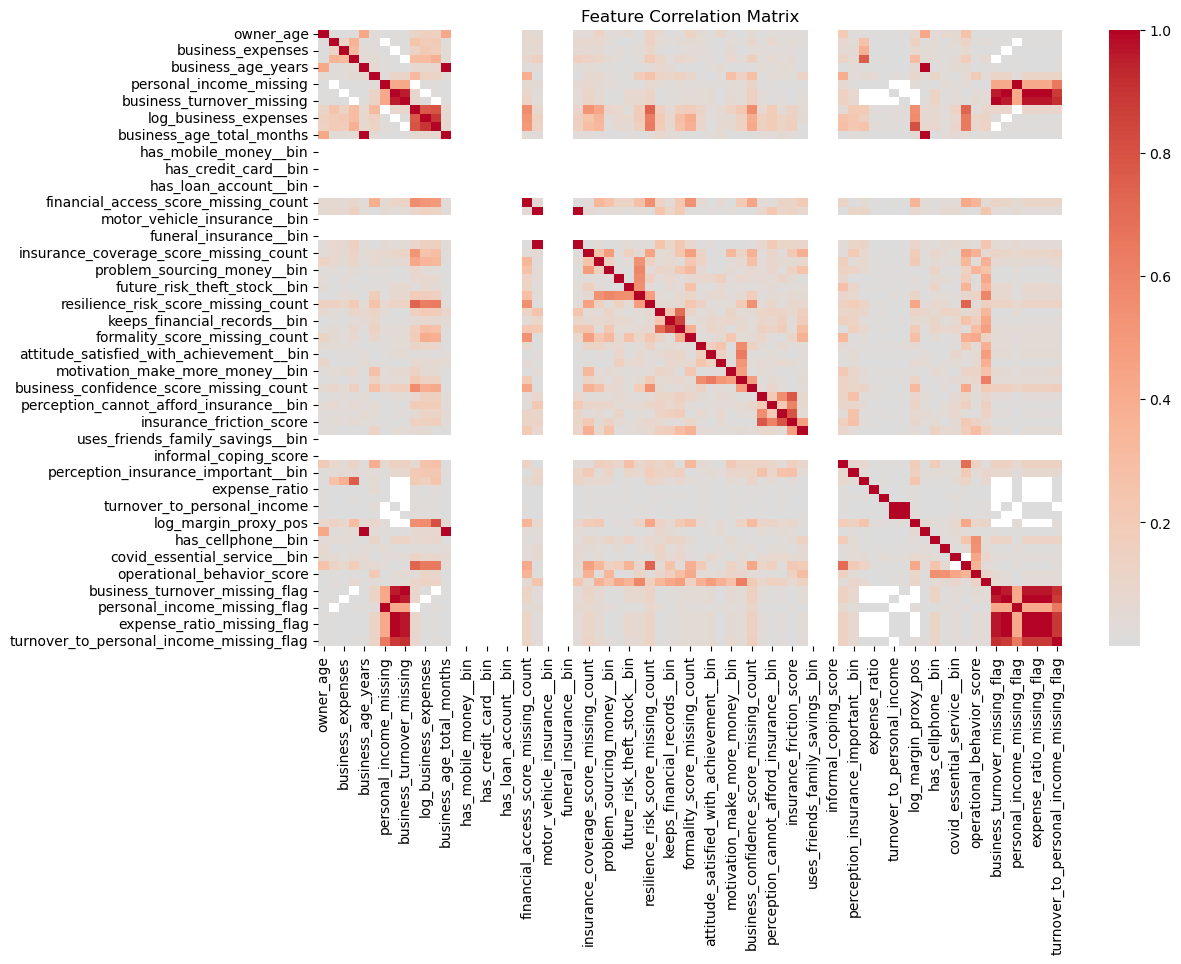

In [40]:
# Visualize

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation Matrix")
plt.show()

### SHAP Feature Importance

SHAP reveals true contribution to predictions

In [41]:
# Train model for SHAP

shap_model = lgb.LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.02,
    num_leaves=128,
    random_state=42
)

shap_model.fit(
    X_corr_pruned,
    y,
    categorical_feature=cat_cols
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001212 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3334
[LightGBM] [Info] Number of data points in the train set: 9618, number of used features: 102
[LightGBM] [Info] Start training from score -3.018659
[LightGBM] [Info] Start training from score -0.426266
[LightGBM] [Info] Start training from score -1.210021
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

,boosting_type,'gbdt'
,num_leaves,128
,max_depth,-1
,learning_rate,0.02
,n_estimators,1200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [42]:
# Compute SHAP values

explainer = shap.TreeExplainer(shap_model)

shap_values = explainer.shap_values(X_corr_pruned)

In [49]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)

<class 'numpy.ndarray'>
9618
(105, 3)


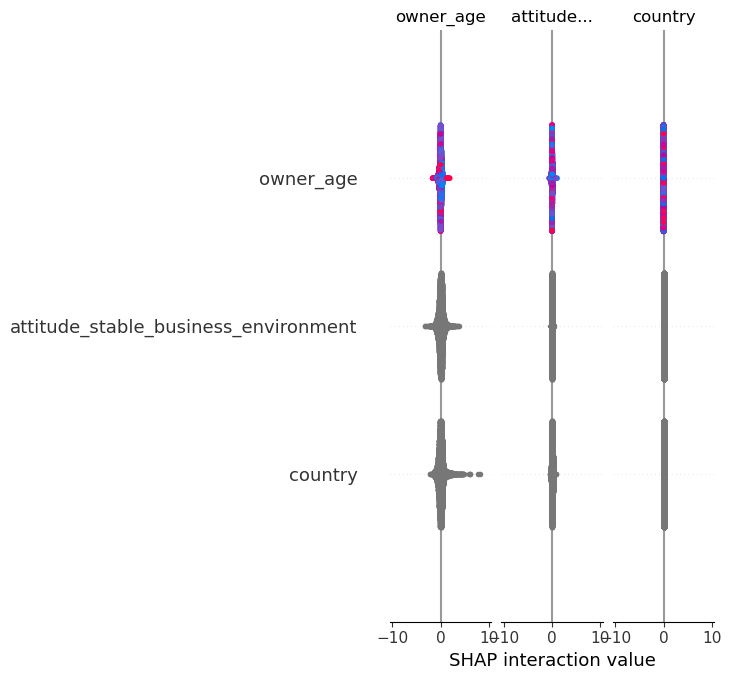

In [43]:
# Global feature impoertance

shap.summary_plot(
    shap_values,
    X_corr_pruned
)

In [45]:
# Convert to numpy array

shap_values = np.array(shap_values)

In [50]:
# Compute global importance

shap_importance = np.abs(shap_values).mean(axis=(0,2))

In [51]:
print(len(X_corr_pruned.columns))
print(len(shap_importance))

105
105


In [52]:
# Create SHAP importnce table 

shap_df = pd.DataFrame({
    "feature": X_corr_pruned.columns,
    "shap_importance": shap_importance
}).sort_values("shap_importance", ascending=False)

In [53]:
shap_df.head(20)

,feature,shap_importance
33,funeral_insurance,1.088572
54,insurance_coverage_score_missing_count,0.662790
102,country_x_has_loan_account,0.530956
49,financial_access_score_missing_count,0.434679
80,perception_insurance_important__bin,0.300338
45,has_credit_card__bin,0.261696
47,has_loan_account__bin,0.246808
22,has_insurance,0.241308
84,turnover_to_personal_income,0.193750
7,personal_income,0.190400


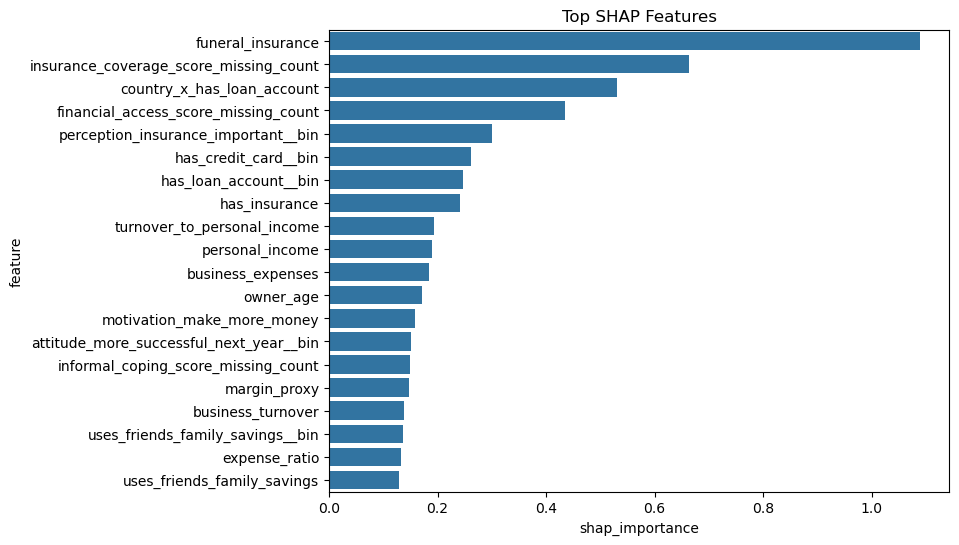

In [55]:
top = shap_df.head(20)

plt.figure(figsize=(8,6))
sns.barplot(data=top, y="feature", x="shap_importance")
plt.title("Top SHAP Features")
plt.show()

### Build Final Feature Ranking

Combine all signals:

+ Combined model importance

+ Permutation importance

+ SHAP importance

In [57]:
# Merge ranking

feature_rank = combined_importance.merge(
    perm_df,
    on="feature"
)

feature_rank = feature_rank.merge(
    shap_df,
    on="feature"
)

In [58]:
# Nromalize scores

for col in ["combined", "perm_importance", "shap_importance"]:
    feature_rank[col] = (
        feature_rank[col] - feature_rank[col].min()
    ) / (
        feature_rank[col].max() - feature_rank[col].min()
    )

In [59]:
# Final importance scores

feature_rank["final_score"] = (
    0.4 * feature_rank["combined"] +
    0.3 * feature_rank["perm_importance"] +
    0.3 * feature_rank["shap_importance"]
)

feature_rank = feature_rank.sort_values(
    "final_score",
    ascending=False
)

In [61]:
# Select final features 

top_features = feature_rank.head(80)["feature"].tolist()

X_final = X_corr_pruned[top_features]
test_final = test_fe[top_features]

### Rebuild Final Ensemble

We now rebuild the CatBoost + LightGBM blend.

In [62]:
# OOF Predictions 

oof_cat = np.zeros((len(X_final), 3))
oof_lgb = np.zeros((len(X_final), 3))

In [64]:
#Update categorical columns for cross validation training 

cat_cols_final = [col for col in cat_cols if col in X_final.columns]

In [65]:
# sanity checks

print("Features in final dataset:", len(X_final.columns))
print("Categorical features used:", cat_cols_final)

all(col in X_final.columns for col in cat_cols_final)

Features in final dataset: 80
Categorical features used: ['attitude_stable_business_environment', 'attitude_worried_shutdown', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'motor_vehicle_insurance', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'attitude_satisfied_with_achievement', 'has_credit_card', 'has_insurance', 'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account', 'has_debit_card', 'future_risk_theft_stock', 'medical_insurance', 'funeral_insurance', 'motivation_make_more_money', 'uses_friends_family_savings', 'country_x_resilience_risk_score', 'country_x_formality_score', 'country_x_business_confidence_score', 'country_x_has_loan_account']


True

In [66]:
# Cross validatopn training

for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y)):

    X_train, X_val = X_final.iloc[train_idx], X_final.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    cat_model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.03,
        depth=8,
        loss_function="MultiClass",
        verbose=False
    )

    cat_model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_cols_final
    )

    lgb_model = lgb.LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.02,
        num_leaves=128
    )

    lgb_model.fit(
        X_train,
        y_train,
        categorical_feature=cat_cols_final
    )

    oof_cat[val_idx] = cat_model.predict_proba(X_val)
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004778 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3203
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 80
[LightGBM] [Info] Start training from score -3.018607
[LightGBM] [Info] Start training from score -0.426214
[LightGBM] [Info] Start training from score -1.210144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

In [67]:
# Blend Predictions Using best weights discovered earlier.
# CatBoost = 0.35
# LightGBM = 0.65

oof_blend = 0.35 * oof_cat + 0.65 * oof_lgb

In [69]:
#Encode the target

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

# Evaluate final OOF score

y_pred = np.argmax(oof_blend, axis=1)

final_f1 = f1_score(y_encoded, y_pred, average="macro")

print("Final OOF Macro F1:", final_f1)

Final OOF Macro F1: 0.7952178209762897


In [71]:
# Train final models on full data

cat_model.fit(X_final, y, cat_features=cat_cols_final)
lgb_model.fit(X_final, y, categorical_feature=cat_cols_final)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3213
[LightGBM] [Info] Number of data points in the train set: 9618, number of used features: 80
[LightGBM] [Info] Start training from score -3.018659
[LightGBM] [Info] Start training from score -0.426266
[LightGBM] [Info] Start training from score -1.210021
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

,boosting_type,'gbdt'
,num_leaves,128
,max_depth,-1
,learning_rate,0.02
,n_estimators,1200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [73]:
#save cat columns from training
cat_cols = X_train.select_dtypes(include="category").columns

#align test dataset categroies
for col in cat_cols:
    test_final[col] = test_final[col].astype("category")
    test_final[col] = test_final[col].cat.set_categories(X_train[col].cat.categories)
    
# Test predictions
test_cat = cat_model.predict_proba(test_final)
test_lgb = lgb_model.predict_proba(test_final)

In [74]:
# Blend test predictions

test_blend = 0.35 * test_cat + 0.65 * test_lgb

In [75]:
# final predcitions

final_preds = np.argmax(test_blend, axis=1)

In [77]:
#create submissions

submission = pd.DataFrame({
    "ID": test_fe["ID"],
    "target": final_preds
})

submission.to_csv("final_submission.csv", index=False)